In [28]:
# Steps after we have a dataframe that contains open-responder IPs.
# Open-responder = open with keepalive + open with notification + open only.
import pandas as pd
df = pd.read_csv("results/open_keepalive_notification_only_02_feb_bonaire_router_mapping.csv",low_memory=False)

# ---- Functions to classify ASNs ----
def is_private_asn(asn):
    """Check if ASN is private."""
    if isinstance(asn, str):
        asn = asn.replace("AS", "").strip()
    try:
        asn = int(asn)
    except ValueError:
        return False
    return (64512 <= asn <= 65534) or (4200000000 <= asn <= 4294967294)

def is_bogon_asn(asn):
    """Check if ASN is reserved or documentation ASN (bogon)."""
    if isinstance(asn, str):
        asn = asn.replace("AS", "").strip()
    try:
        asn = int(asn)
    except ValueError:
        return False
    return (
        asn == 0 or
        asn == 65535 or
        asn == 4294967295 or
        64496 <= asn <= 64511 or
        65536 <= asn <= 65551  # include documentation/test ASNs

    )


# ---- Categories ----
# Now classify based on effective_asn
no_asn = df[df["effective_asn"].isna() | (df["effective_asn"] == "")]
asn_23456 = df[df["effective_asn"] == 23456]

private_asn_only = df[
    df["effective_asn"].notna() &
    df["effective_asn"].apply(is_private_asn)
]

bogon_asn_only = df[
    df["effective_asn"].notna() &
    df["effective_asn"].apply(is_bogon_asn)
]

public_asn_only = df[
    df["effective_asn"].notna() &
    (~df["effective_asn"].apply(is_private_asn)) &
    (~df["effective_asn"].apply(is_bogon_asn)) &
    (df["effective_asn"] != 23456)
]
print(f"IP addresses with public ASNs: {len(public_asn_only)}")
print(f"IP addresses with private ASNs (excluding AS23456): {len(private_asn_only)}")
print(f"IP addresses with bogon/reserved ASNs: {len(bogon_asn_only)}")
print(f"IP addresses with AS23456: {len(asn_23456)}")
print(f"IP addresses with no ASNs: {len(no_asn)}")

IP addresses with public ASNs: 119691
IP addresses with private ASNs (excluding AS23456): 13641
IP addresses with bogon/reserved ASNs: 232
IP addresses with AS23456: 7749
IP addresses with no ASNs: 0


In [ ]:
# Find ASNs from router ID also using ipinfo.
import pandas as pd
import numpy as np
import ipaddress

bgp_file = "results/open_keepalive_notification_only_02_feb_bonaire_router_mapping.csv"
asn_file = "data/2026-02-02_country_asn.csv"
output_file = "results/open_keepalive_notification_only_with_asn_from_router_id_02_feb_bonaire_router_mapping.csv"

# --- Step 1: Load BGP file ---
df = pd.read_csv(
    bgp_file, 
     usecols=
        ["target_ip", "date",  "router_key","tags_honeypot", "asn", "is_non_public_asn", "effective_asn"],
    low_memory=False)

# Get router ID from router_key (FIXED SYNTAX ERROR)
df["router_id"] = df["router_key"].str.partition("_")[0]


# --- Step 2: Load ASN bulk file ---
df_asn = pd.read_csv(asn_file)

# Convert IP ranges to integers
# Keep only IPv4 ranges
df_asn = df_asn[df_asn["start_ip"].str.contains(r"\.")].copy()

df_asn["start_int"] = df_asn["start_ip"].apply(lambda x: int(ipaddress.IPv4Address(x)))
df_asn["end_int"] = df_asn["end_ip"].apply(lambda x: int(ipaddress.IPv4Address(x)))

df_asn["start_int"] = df_asn["start_ip"].apply(lambda x: int(ipaddress.IPv4Address(x)))
df_asn["end_int"] = df_asn["end_ip"].apply(lambda x: int(ipaddress.IPv4Address(x)))

# Sort ranges
df_asn = df_asn.sort_values("start_int").reset_index(drop=True)

starts = df_asn["start_int"].values
ends = df_asn["end_int"].values
asns = df_asn["asn"].values


# Function to map IP to ASN
def map_asn(ip_str):
    try:
        ip_int = int(ipaddress.IPv4Address(ip_str))
        idx = np.searchsorted(starts, ip_int, side="right") - 1
        if idx >= 0 and ip_int <= ends[idx]:
            return str(asns[idx])
    except Exception:
        pass
    return ""


# --- Step 3: Map router_id to ASN (NOT target_ip) ---
df["asn_from_router_id"] = df["router_id"].apply(map_asn)


# Clean ASN format
df["asn_from_router_id"] = (
    df["asn_from_router_id"]
        .astype(str)
        .str.replace("AS", "", regex=False)
        .str.strip()
)

# Convert to numeric
df["asn_from_router_id"] = pd.to_numeric(df["asn_from_router_id"], errors="coerce")

# Create a new column 'router_id_is_private'
df["router_id_is_private"] = df["router_id"].apply(
    lambda x: ipaddress.ip_address(x).is_private
)

# Define desired column order
column_order = [
    "target_ip",
    "date",
    "router_key",
    "tags_honeypot",
    "router_id",
    "asn",
    "is_non_public_asn",
    "effective_asn",
    "asn_from_router_id",
    "router_id_is_private"
]

# Reorder dataframe
df = df[column_order]

# Save
df.to_csv(output_file, index=False)
print(f"Saved final router mapping to {output_file}")

In [6]:
# Get ASN based on target IP that is required for the cases of private BGP ID and non-public ASNs.
import pandas as pd
import numpy as np
import ipaddress

df = pd.read_csv("results/open_keepalive_notification_only_with_asn_from_router_id_02_feb_bonaire_router_mapping.csv", low_memory=False)
output_file = "results/open_keepalive_notification_only_with_asn_from_router_id_target_ip_02_feb_bonaire_router_mapping.csv"


# Select the rows to update
mask = (
    ((df["effective_asn"] == 23456) & (df["router_id_is_private"] == False)) |
    ((df["router_id_is_private"] == True) & (df["is_non_public_asn"] == True))
)

# Apply mask to filter
filtered_df = df[mask]


# Apply map_asn only to the target_ip of these rows
df.loc[mask, "effective_asn"] = df.loc[mask, "target_ip"].apply(map_asn)

# --- Step 2: Load ASN bulk file ---
df_asn = pd.read_csv(asn_file)

# Keep only IPv4 ranges safely
df_asn = df_asn[df_asn["start_ip"].str.contains(r"\.", na=False)].copy()

# Convert IP ranges to integers
df_asn["start_int"] = df_asn["start_ip"].apply(lambda x: int(ipaddress.IPv4Address(x)))
df_asn["end_int"]   = df_asn["end_ip"].apply(lambda x: int(ipaddress.IPv4Address(x)))

# Sort ranges
df_asn = df_asn.sort_values("start_int").reset_index(drop=True)

starts = df_asn["start_int"].values
ends   = df_asn["end_int"].values
asns   = df_asn["asn"].values

# --- ASN Mapping Function ---
def map_asn(ip_str):
    try:
        ip_str = str(ip_str).strip()
        ip_int = int(ipaddress.IPv4Address(ip_str))
        idx = np.searchsorted(starts, ip_int, side="right") - 1
        if idx >= 0 and ip_int <= ends[idx]:
            asn_value = asns[idx]
            if isinstance(asn_value, str):
                asn_value = asn_value.replace("AS", "").strip()
            return int(asn_value)
    except Exception as e:
        print("Error mapping IP:", ip_str, "|", e)
    return None

# --- Step 3: Apply map_asn only to rows matching the mask ---
mask = (df["effective_asn"] == 23456) & (df["router_id_is_private"] == False)

# Apply mapping with fallback to existing effective_asn if mapping fails
df.loc[mask, "effective_asn"] = df.loc[mask, "target_ip"].apply(
    lambda ip: map_asn(ip) if map_asn(ip) is not None else 23456
)

# --- Optional: add asn_from_target_ip column for reference ---
df["asn_from_target_ip"] = df["target_ip"].apply(map_asn)
df["asn_from_target_ip"] = pd.to_numeric(df["asn_from_target_ip"], errors="coerce")

# Fix the two IPs manually (if needed)
df.loc[df["target_ip"] == "157.66.38.254", "asn_from_target_ip"] = 63865
df.loc[df["target_ip"] == "177.210.105.1", "asn_from_target_ip"] = 134175
df.loc[df["target_ip"] == "45.8.23.254", "asn_from_target_ip"] = 29119
df.loc[df["target_ip"] == "163.223.37.2", "asn_from_target_ip"] = 152384 
df.loc[df["target_ip"] == "163.223.37.0", "asn_from_target_ip"] = 152384 
df.loc[df["target_ip"] == "91.92.40.1", "asn_from_target_ip"] = 215762 
df.loc[df["target_ip"] == "85.122.114.1", "asn_from_target_ip"] = 200019 

df.loc[:, "effective_asn"] = df["effective_asn"].str.replace("AS", "", regex=False)

# For other cases with public ASN, replace effective_asn = asn.
df.loc[
    df["is_non_public_asn"] == False,  # mask
    "effective_asn"                    # column to update
] = df.loc[
    df["is_non_public_asn"] == False,
    "asn"                              # values to assign
]

# For public router ID but non-public ASN, effective ASN = ASN from  router ID
mask2 = (df["router_id_is_private"] == False) & (df["is_non_public_asn"] == True)

df.loc[mask2, "effective_asn"] = df.loc[mask2, "asn_from_router_id"]

# Some IP addresses have effective_asn is NA because the router ID was public and ASN was private or 23456.
# And the public IP address was bogon so IPinfo didn't find the records.
# There were 501 such IP addresses.
# print("There were 501 IP addresses whose router ID was public and ASN was private or 23456, and IPinfo didn't find the records.")
# print("\n Using asn_from_target_ip for cases where effective_asn.isna() and asn is non public.")

mask3 = (df["effective_asn"].isna()) & (df["is_non_public_asn"] == True)
# print(f"Number of such cases {len(df[mask3])}")
df.loc[mask3, "effective_asn"] = df.loc[mask3, "asn_from_target_ip"]


# Save to CSV
df.to_csv(output_file, index=False)
print(f"Saved final router mapping to {output_file}")


Error mapping IP: 157.66.38.254 | cannot convert float NaN to integer
Error mapping IP: 177.210.105.1 | cannot convert float NaN to integer
Error mapping IP: 45.8.23.254 | cannot convert float NaN to integer
Error mapping IP: 163.223.37.2 | cannot convert float NaN to integer
Error mapping IP: 163.223.37.0 | cannot convert float NaN to integer
Error mapping IP: 91.92.40.1 | cannot convert float NaN to integer
Error mapping IP: 85.122.114.1 | cannot convert float NaN to integer
Saved final router mapping to results/open_keepalive_notification_only_with_asn_from_router_id_target_ip_02_feb_bonaire_router_mapping.csv


In [7]:
# Both router ID and ASN in open message are public, and ASNs from router ID is the same as of router ID.
# -> Likely an edge router.
import pandas as pd
df_orig = pd.read_csv("results/open_keepalive_notification_only_with_asn_from_router_id_target_ip_02_feb_bonaire_router_mapping.csv", low_memory=False)

router_id_asn_both_same_and_public = df_orig[
    (df_orig["is_non_public_asn"] == False)
    & (~df_orig["router_id_is_private"])
    & (
        df_orig["asn_from_router_id"].fillna(df_orig["asn"]) == df_orig["asn"] # For some router IDs, ipinfo didn't show ASN.
    )
]
print("# Public IP as a router ID and public ASN in BGP config, and both have same ASN - likely an Edge router.")

print(f"# of IP addresses {router_id_asn_both_same_and_public['target_ip'].nunique()}, # of routers {router_id_asn_both_same_and_public['router_key'].nunique()}, # of ASes {router_id_asn_both_same_and_public['effective_asn'].nunique()}")


# Public IP as a router ID and public ASN in BGP config, and both have same ASN - likely an Edge router.
# of IP addresses 58581, # of routers 5294, # of ASes 1404


In [8]:
# Both router ID and ASN in open message are public, and ASNs from router ID is different than router ID.
# -> Likely hosted/manged infrastructure or BYOIP.
# The sibling ASes too of an organization.

router_id_asn_diff_than_asn_and_public = df_orig[
     (df_orig["is_non_public_asn"] == False)
     & (df_orig["router_id_is_private"] == False) 
    & (df_orig["asn_from_router_id"] != df_orig["asn"])
    & (df_orig["asn_from_router_id"].notna())
]
print("# Public IP as a router ID and public ASN in BGP config, and both have different ASN - likely a BYOIP")
print(f"# of IP addresses {router_id_asn_diff_than_asn_and_public['target_ip'].nunique()}, # of routers {router_id_asn_diff_than_asn_and_public['router_key'].nunique()}, # of ASes {router_id_asn_diff_than_asn_and_public['effective_asn'].nunique()}")

# Public IP as a router ID and public ASN in BGP config, and both have different ASN - likely a BYOIP
# of IP addresses 7744, # of routers 912, # of ASes 397


In [9]:
# Router ID is a private IP, and ASN in open message is public.
# -> Common in ISPs, hard to tell.
router_id_private_asn_public = df_orig[(df_orig["router_id_is_private"] == True) 
                                  & (df_orig["is_non_public_asn"] == False)
                                     ]
print("# Private IP as a router ID and public ASN in BGP config - difficult to categorize a router.")
print(f"# of IP addresses {router_id_private_asn_public['target_ip'].nunique()}, # of routers {router_id_private_asn_public['router_key'].nunique()}, # of ASes {router_id_private_asn_public['effective_asn'].nunique()}")

# Private IP as a router ID and public ASN in BGP config - difficult to categorize a router.
# of IP addresses 24138, # of routers 2741, # of ASes 940


In [10]:
# Router ID is a public IP, and ASN in open message is a private.
# -> Likely a core/internal router 
router_id_public_asn_non_public = df_orig[(df_orig["router_id_is_private"] == False) 
                                  & (df_orig["is_non_public_asn"] == True)
                                     ]
# Remove "AS" prefix if present
# router_id_public_asn_non_public.loc[:, "effective_asn"] = router_id_public_asn_non_public["effective_asn"].str.replace("AS", "", regex=False)
print("# Public IP as a router ID and non-public ASN in BGP config - likely internal router")
print(f"# of IP addresses {router_id_public_asn_non_public['target_ip'].nunique()}, # of routers {router_id_public_asn_non_public['router_key'].nunique()}, # of ASes {router_id_public_asn_non_public['effective_asn'].nunique()}")

# Public IP as a router ID and non-public ASN in BGP config - likely internal router
# of IP addresses 31057, # of routers 7890, # of ASes 1254


In [11]:
# Router ID is a private IP, and ASN in open message is also private.
# -> Likely a core/internal router 
router_id_private_asn_non_public = df_orig[(df_orig["router_id_is_private"] == True) 
                                  & (df_orig["is_non_public_asn"] == True)
                                     ]
# Case where router id and asn is non-public, but effective_asn is na, use asn_from_target_ip
mask4 = (router_id_private_asn_non_public["effective_asn"].isna())
router_id_private_asn_non_public.loc[mask4, "effective_asn"] = router_id_private_asn_non_public.loc[mask4, "asn_from_target_ip"]
router_id_private_asn_non_public[router_id_private_asn_non_public["effective_asn"].isna()]

print("# Private IP as a router ID and non-public ASN in BGP config")
print(f"# of IP addresses {router_id_private_asn_non_public['target_ip'].nunique()}, # of routers {router_id_private_asn_non_public['router_key'].nunique()}, # of ASes {router_id_private_asn_non_public['effective_asn'].nunique()}")

# unique_routers_count = router_id_private_asn_non_public.groupby(["router_key", "effective_asn"]).ngroups
# print("Number of unique routers:", unique_routers_count)

# print("NOTE: # of ASes is different based on ASN found from target_ip in next step.")

# Private IP as a router ID and non-public ASN in BGP config
# of IP addresses 19793, # of routers 6175, # of ASes 1373


In [12]:
# merge all those dataframes into one
import pandas as pd

merged_patterns = pd.concat([
    router_id_asn_both_same_and_public,
    router_id_asn_diff_than_asn_and_public,
    router_id_private_asn_public,
    router_id_public_asn_non_public,
    router_id_private_asn_non_public
], ignore_index=True)

In [17]:
# identify routers (or target IPs) that appear with multiple ASNs, because that may indicate border routers connecting different ASes. 
df = router_id_asn_both_same_and_public
# Count unique ASNs per router (or per target IP)
# Count how many unique ASNs each router_key appears in
asn_counts = df.groupby('router_key')['asn_from_target_ip'].nunique().reset_index()
asn_counts.rename(columns={'asn_from_target_ip': 'unique_asn_count'}, inplace=True)

# Keep only routers that appear in more than one ASN
border_routers = asn_counts[asn_counts['unique_asn_count'] > 1]

# Sort descending by number of ASNs
border_routers = border_routers.sort_values(by='unique_asn_count', ascending=False)

print(border_routers["unique_asn_count"])
print(f"Sum of border routers: {border_routers['unique_asn_count'].sum()}")

4791    22
2544    11
248     11
1719    10
3535    10
        ..
1911     2
1909     2
1903     2
1885     2
5290     2
Name: unique_asn_count, Length: 1720, dtype: int64
Sum of border routers: 4407


In [26]:
# Build a per-AS router composition table
import pandas as pd

# Add pattern label to each df
router_id_asn_both_same_and_public["pattern"] = "p1"
router_id_asn_diff_than_asn_and_public["pattern"] = "p2"
router_id_private_asn_public["pattern"] = "p3"
router_id_public_asn_non_public["pattern"] = "p4"
router_id_private_asn_non_public["pattern"] = "p5"

# Combine all
all_routers = pd.concat(df_list, ignore_index=True)

# Count routers per ASN per pattern

summary = (
    all_routers
    .groupby(["effective_asn", "pattern"])["router_key"]
    .nunique()
    .unstack(fill_value=0)
)

summary["total_routers"] = summary.sum(axis=1)
summary = summary.reset_index()


summary

/tmp/ipykernel_24548/4242283119.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  router_id_asn_both_same_and_public["pattern"] = "p1"
/tmp/ipykernel_24548/4242283119.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  router_id_asn_diff_than_asn_and_public["pattern"] = "p2"
/tmp/ipykernel_24548/4242283119.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://p

pattern,effective_asn,p1,p2,p3,p4,p5,total_routers
0,1,0,1,4,0,0,5
1,2,0,1,1,0,0,2
2,10,0,0,2,0,0,2
3,22,0,1,0,0,0,1
4,25,0,0,0,4,0,4
...,...,...,...,...,...,...,...
4399,4145956121,1,0,0,0,0,1
4400,4145976425,1,0,0,0,0,1
4401,4152246233,0,0,1,0,0,1
4402,4152275513,0,1,0,0,0,1


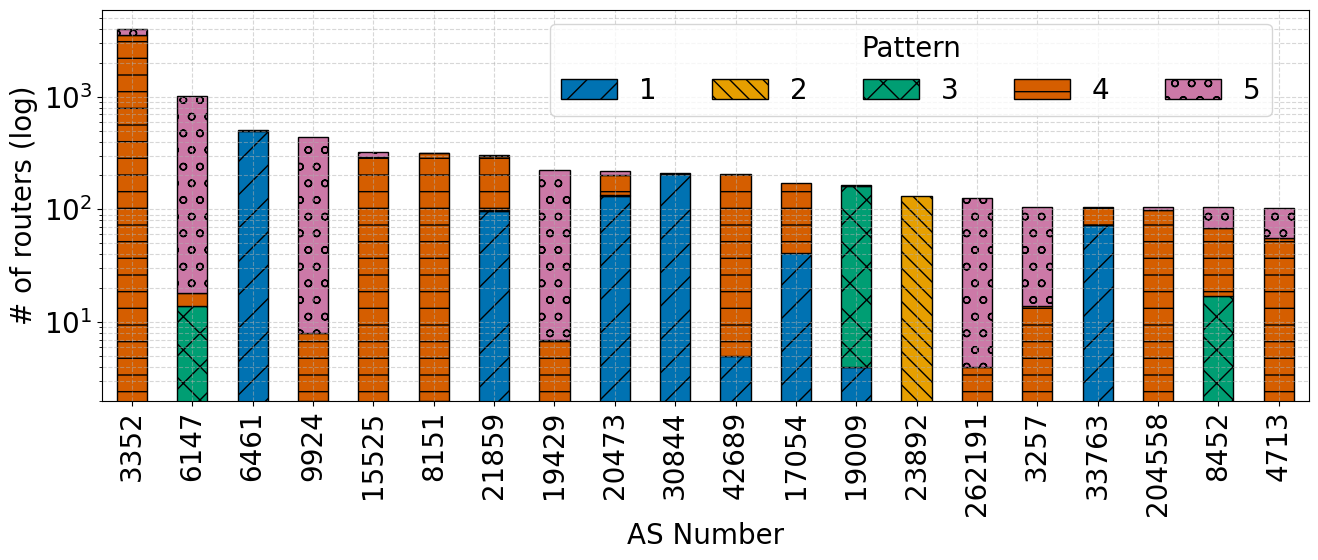

In [27]:
top20 = summary.sort_values("total_routers", ascending=False).head(20)



import matplotlib.pyplot as plt
# ---------- IEEE-style global settings ----------
plt.rcParams.update({
    'font.size': 20,
    'axes.labelsize': 20,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
})
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

# Colorblind-friendly palette (Okabe–Ito)
colors = [
    "#0072B2",  # blue
    "#E69F00",  # orange
    "#009E73",  # green
    "#D55E00",  # vermillion
    "#CC79A7"   # purple
]

# Hatch patterns (clearly distinguishable)
hatches = ['/', '\\\\', 'x', '-', 'o']

# Rename columns
plot_df = top20.rename(columns={
    "p1": "1",
    "p2": "2",
    "p3": "3",
    "p4": "4",
    "p5": "5"
})

# Format ASN index
# Set the index
plot_df = plot_df.set_index("effective_asn")

# Convert float-like strings to int, then to str
plot_df.index = plot_df.index.map(lambda x: str(int(float(x))) if pd.notna(x) else "")

# plot_df.index = "AS" + plot_df.index

# Plot
ax = plot_df[["1", "2", "3", "4", "5"]].plot(
    kind="bar",
    stacked=True,
    figsize=(14, 6),
    color=colors,
    edgecolor="black"
)

# Apply hatch patterns per stack
for i, bar_container in enumerate(ax.containers):
    for bar in bar_container:
        bar.set_hatch(hatches[i])
plt.yscale("log")
plt.ylabel("# of routers (log)")
plt.xlabel("AS Number")
plt.legend(title="Pattern", bbox_to_anchor=(0.36, 1), loc="upper left", ncols = 5)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("images/router_deployment_top_20_ases.pdf")
plt.show()

In [14]:
import pandas as pd

# Example top20

# Group 1: internal routers (p4 + p5)
top20["internal"] = top20["p4"] + top20["p5"]

# Group 2: remaining patterns (p1 + p2 + p3)
top20["external"] = top20["p1"] + top20["p2"] + top20["p3"]

# Keep only relevant columns if desired
grouped_df = top20[["effective_asn", "internal", "external"]]

# print(grouped_df)
sum_internal = grouped_df["internal"].sum()
sum_external = grouped_df["external"].sum()

print("Total internal routers are %s and external routers are %s" % (sum_internal, sum_external))

Total internal routers are 7514 and external routers are 1378


Total routers we found are 8871 and details are:
      enterprise  num_routers
0   9.000000e+00           25
1   2.007000e+03         2956
2   2.011000e+03            9
3   2.636000e+03         5448
4   3.902000e+03            1
5   8.072000e+03           32
6   1.498800e+04           87
7   1.908874e+07           88
8   3.054199e+08          207
9   8.084644e+08            2
10  1.970372e+09           13
11  1.970372e+09            2
12  1.970373e+09            1


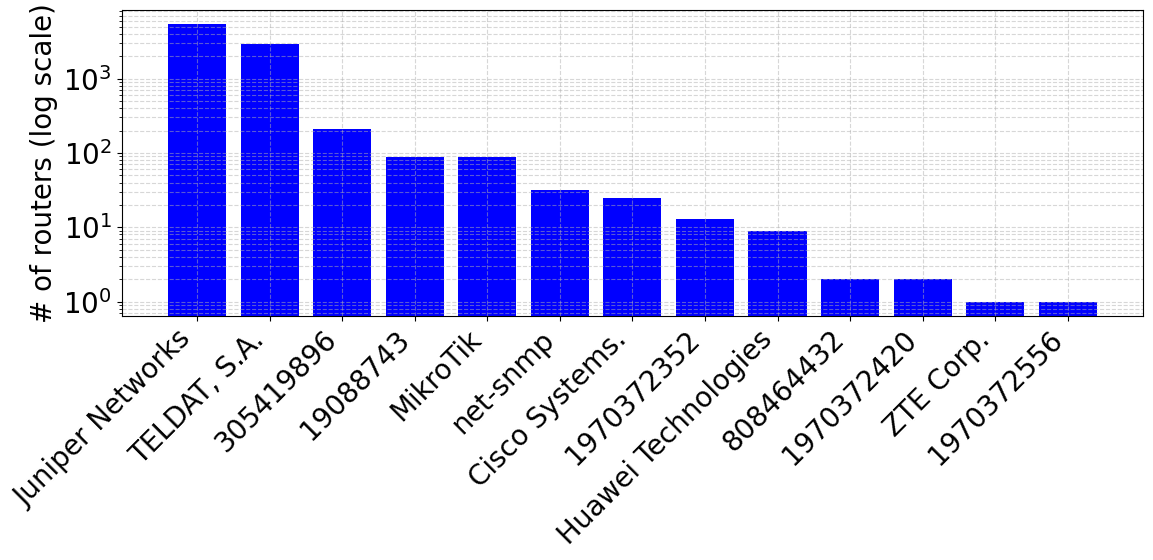

In [54]:
"""
Check analyses after this part in private_public_asns.ipynb

# Shodan query to get vendor information routers for open-responder
shodan_vendor = pd.read_csv("data/shodan_snmp_results_open_keepalive_notification_only_02_feb_bonaire_router_mapping.csv")
shodan_vendor_with_enterprise = shodan_vendor[~shodan_vendor["enterprise"].isna()]
shodan_vendor_with_enterprise

merged_vendor_patterns = pd.merge(
    merged_patterns,
    shodan_vendor_with_enterprise,
    left_on='target_ip',
    right_on='ip',
    how='left'
)



# Count the number of unique routers per vendor
routers_per_vendor = merged_vendor_patterns.groupby('enterprise')['router_id'].nunique().reset_index()
routers_per_vendor = routers_per_vendor.rename(columns={'router_id': 'num_routers'})
print("Total routers we found are %s and details are:\n%s" % (
    routers_per_vendor['num_routers'].sum(),
    routers_per_vendor
))

# ---------- IEEE-style global settings ----------
plt.rcParams.update({
    'font.size': 20,
    'axes.labelsize': 20,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
})
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

# Known vendor names (unknowns as None for now)
enterprise_numbers = routers_per_vendor['enterprise']
vendor_names = [
    "Cisco Systems.",
    "TELDAT, S.A.",
    "Huawei Technologies",
    "Juniper Networks",
    "ZTE Corp.",
    "net-snmp",
    None,
    None,
    None,
    None,
    None,
    None,
    None
]

# Replace None with the enterprise number itself
vendor_names = [name if name is not None else str(num) 
                for num, name in zip(enterprise_numbers, vendor_names)]

# Create the mapping dataframe
enterprise_mapping_df = pd.DataFrame({
    'enterprise': enterprise_numbers,
    'enterprise_name_mapped': vendor_names
})

# Ensure 'enterprise' column in both dataframes is i2636nteger
routers_per_vendor['enterprise'] = routers_per_vendor['enterprise'].astype(int)
enterprise_mapping_df['enterprise'] = enterprise_mapping_df['enterprise'].astype(int)

# Merge again
routers_with_names = pd.merge(
    routers_per_vendor,
    enterprise_mapping_df,
    on='enterprise',
    how='left'
)

# Keep only the mapped enterprise name and number of routers
routers_with_names = routers_with_names[['enterprise_name_mapped', 'num_routers']]

# Optionally, rename the column to something clean
routers_with_names = routers_with_names.rename(columns={'enterprise_name_mapped': 'enterprise_name'})


# Convert enterprise_name column to int if it’s numeric, then to string
routers_with_names['enterprise_name'] = routers_with_names['enterprise_name'].apply(
    lambda x: str(int(x)) if isinstance(x, float) else str(x)
)

# Display the final result
import matplotlib.pyplot as plt

# Map known enterprise numbers to names (add MikroTik as an example)
enterprise_name_map = {
    14988: "MikroTik",
    # Add more mappings here if needed
}

def clean_enterprise_name(x):
    if x is None:
        return "Unknown"

    # Convert to string for safe processing
    x_str = str(x)

    # If numeric, normalize it
    try:
        num = int(float(x_str))
        if num in enterprise_name_map:
            return enterprise_name_map[num]
        return str(num)  # removes .0
    except ValueError:
        return x_str  # already a vendor name

routers_with_names['enterprise_name'] = routers_with_names['enterprise_name'].apply(clean_enterprise_name)


# Sort by number of routers descending for better visualization
routers_plot = routers_with_names.sort_values(by='num_routers', ascending=False)

# Plot
plt.figure(figsize=(12, 6))
plt.bar(routers_plot['enterprise_name'], routers_plot['num_routers'], color='blue')
plt.xticks(rotation=45, ha='right')  # Rotate names for readability
# plt.xlabel('Enterprise Name')
plt.ylabel('# of routers (log scale)')
plt.yscale('log')
# plt.title('# of routers per enterprise/vendor')
plt.grid(True, which='both', linestyle='--', alpha=0.5)

plt.tight_layout()  # Adjust layout to prevent clipping of labels
plt.savefig("images/router_vendors.pdf")
plt.show()
# merged_patterns[merged_patterns["effective_asn"].isna()]
"""

In [52]:
vendor_names

['Cisco Systems.',
 'TELDAT, S.A.',
 'Huawei Technologies',
 'Juniper Networks',
 'ZTE Corp.',
 'net-snmp',
 '14988.0',
 '19088743.0',
 '305419896.0',
 '808464432.0',
 '1970372352.0',
 '1970372420.0',
 '1970372556.0']

In [28]:
# Group by AS (effective_asn) and vendor

# Ensure 'enterprise' column in both dataframes is integer
routers_per_vendor['enterprise'] = routers_per_vendor['enterprise'].astype(int)
enterprise_mapping_df['enterprise'] = enterprise_mapping_df['enterprise'].astype(int)

vendor_asn_counts = merged_vendor_patterns.groupby(
    ['effective_asn', 'enterprise']
)['router_id'].nunique().reset_index()

# Map enterprise numbers to vendor names
vendor_asn_counts = vendor_asn_counts.merge(
    enterprise_mapping_df,
    on='enterprise',
    how='left'
)

# Rename column for clarity
vendor_asn_counts = vendor_asn_counts.rename(
    columns={'enterprise_name_mapped': 'enterprise_name', 'router_id': 'num_routers'}
)

vendor_asn_counts
# Sum total routers per AS
as_totals = vendor_asn_counts.groupby('effective_asn')['num_routers'].sum().reset_index()

In [32]:
as_totals.sort_values("num_routers", ascending=False).head(20)

,effective_asn,num_routers
71,3352.0,1475
128,6147.0,992
359,15525.0,320
185,8151.0,312
463,20473.0,214
891,42689.0,202
451,19429.0,202
689,30844.0,195
305,12252.0,76
481,21859.0,73


/tmp/ipykernel_25837/407510996.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_vendor_asn_counts["effective_asn"] = top_vendor_asn_counts["effective_asn"].astype(int)


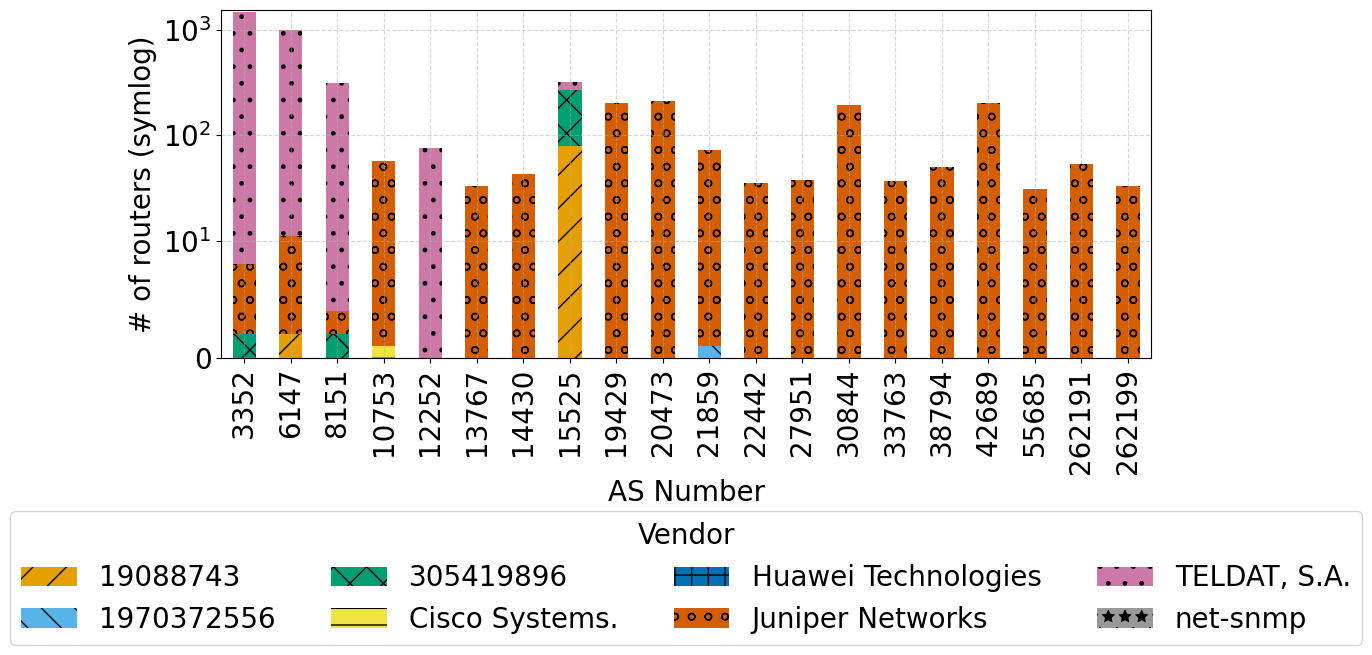

In [46]:
"""
# Plot vendor distribution across top 20 ASes
# Get top 20 ASes by total routers
# Ensure effective_asn is int
import matplotlib.pyplot as plt

colors = [
    "#E69F00",  # orange
    "#56B4E9",  # sky blue
    "#009E73",  # bluish green
    "#F0E442",  # yellow
    "#0072B2",  # blue
    "#D55E00",  # vermillion
    "#CC79A7",  # reddish purple
    "#999999"   # grey
]

hatches = ['/', '\\', 'x', '-', '+', 'o', '.', '*']

top_asns = as_totals.nlargest(20, 'num_routers')['effective_asn']

# Filter for top ASes
top_vendor_asn_counts = vendor_asn_counts[vendor_asn_counts['effective_asn'].isin(top_asns)]

# top_vendor_asn_counts = vendor_asn_counts.sort_values("num_routers", ascending=False).head(20)

# Ensure effective_asn is int
top_vendor_asn_counts["effective_asn"] = top_vendor_asn_counts["effective_asn"].astype(int)

# Order vendors by total routers so smallest is at the bottom
vendor_order = pivot_df.sum().sort_values().index

# Pivot
pivot_df = top_vendor_asn_counts.pivot(
    index='effective_asn', columns='enterprise_name', values='num_routers'
).fillna(0)


# Remove trailing .0 from columns that look like numbers
pivot_df.columns = [
    str(int(float(c))) if c.replace('.','',1).isdigit() else c 
    for c in pivot_df.columns
]
# Plot stacked bar
ax = pivot_df.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6),
    color=colors
)

# Apply hatch patterns
for i, bar_container in enumerate(ax.containers):
    for bar in bar_container:
        bar.set_hatch(hatches[i % len(hatches)])

plt.xlabel('AS Number')
# plt.ylabel('# of routers (log scale)')
plt.ylabel('# of routers (symlog)')
plt.yscale("symlog", linthresh=10)

ax.legend(
    [str(label) for label in pivot_df.columns],
    title='Vendor',
    bbox_to_anchor=(0.5,-0.40),
    ncols=4,
    loc='upper center'
)

plt.subplots_adjust(bottom=0.3)
plt.grid(True, which='both', linestyle='--', alpha=0.5)

plt.savefig("images/vendor_across_ases.pdf", bbox_inches='tight')
plt.show()
"""


In [36]:
pivot_df

,19088743,1970372556,305419896,Cisco Systems.,Huawei Technologies,Juniper Networks,"TELDAT, S.A.",net-snmp
effective_asn,,,,,,,,
3352,0.0,0.0,2.0,0.0,0.0,6.0,1467.0,0.0
6147,2.0,0.0,0.0,0.0,0.0,9.0,977.0,4.0
8151,0.0,0.0,2.0,0.0,0.0,2.0,308.0,0.0
10753,0.0,0.0,0.0,1.0,0.0,56.0,0.0,0.0
12252,0.0,0.0,0.0,0.0,0.0,0.0,76.0,0.0
13767,0.0,0.0,0.0,0.0,0.0,33.0,0.0,0.0
14430,0.0,0.0,0.0,0.0,0.0,43.0,0.0,0.0
15525,79.0,0.0,190.0,0.0,3.0,0.0,48.0,0.0
19429,0.0,0.0,0.0,0.0,0.0,201.0,0.0,1.0


In [31]:
# Remove trailing .0 from columns that look like numbers
pivot_df.columns = [
    str(int(float(c))) if c.replace('.','',1).isdigit() else c 
    for c in pivot_df.columns
]
pivot_df.columns

Index(['19088743', '1970372556', '305419896', 'Cisco Systems.',
       'Huawei Technologies', 'Juniper Networks', 'TELDAT, S.A.', 'net-snmp'],
      dtype='object')

In [ ]:
import pandas as pd 
notification_only = pd.read_csv("results/notification_only_02_feb_bonaire_router_mapping.csv")
no_asns = notification_only["effective_asn"].nunique()
no_target_ips = notification_only["target_ip"].nunique()
print("Notification-only responders: No. of ASNs = %s, no. of target IPs = %s" %(no_asns, no_target_ips))

In [ ]:
# Percentage wise distribution
top20 = summary.sort_values("total_routers", ascending=False).head(20)

top20_norm = top20.copy()
patterns = ["p1","p2","p3","p4","p5"]

top20_norm[patterns] = top20_norm[patterns].div(
    top20_norm["total_routers"], axis=0
)
top20 = top20_norm.copy()
# Rename columns
plot_df = top20.rename(columns={
    "p1": "1",
    "p2": "2",
    "p3": "3",
    "p4": "4",
    "p5": "5"
})

# Format ASN index
# Set the index
plot_df = plot_df.set_index("effective_asn")

# Convert float-like strings to int, then to str
plot_df.index = plot_df.index.map(lambda x: str(int(float(x))) if pd.notna(x) else "")


# plot_df.index = "AS" + plot_df.index

# Plot
ax = plot_df[["1", "2", "3", "4", "5"]].plot(
    kind="bar",
    stacked=True,
    figsize=(14, 6),
    color=colors,
    edgecolor="black"
)

# Apply hatch patterns per stack
for i, bar_container in enumerate(ax.containers):
    for bar in bar_container:
        bar.set_hatch(hatches[i])
# plt.yscale("log")
plt.ylabel("# of routers (log)")
plt.xlabel("ASN")
plt.legend(title="Pattern", bbox_to_anchor=(0.36, 1), loc="upper left", ncols = 5)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("images/router_deployment_top_20_ases_percentage.pdf")
plt.show()

In [ ]:
a = routers_per_asn.sort_values("unique_router_count", ascending=False)
# a
b = ips_per_router.sort_values("no_of_ips", ascending=False)
# b

In [ ]:
# Pattern 2: CDF plots of number of routers per AS, and number of IPs per router.


# ---------- IEEE-style global settings ----------
plt.rcParams.update({
    'font.size': 20,
    'axes.labelsize': 20,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
})
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

# -----------------------------
# CDF of number of routers per ASN
# -----------------------------
routers_per_asn = (
    router_id_asn_diff_than_asn_and_public
        .groupby("effective_asn")["router_key"]
        .nunique()
        .reset_index()
        .rename(columns={"router_key": "unique_router_count"})
)

sorted_router_counts = routers_per_asn['unique_router_count'].sort_values()
cdf_routers = sorted_router_counts.rank(method='first') / len(sorted_router_counts)

# -----------------------------
# CDF of number of IPs per router
# -----------------------------
ips_per_router = (
    router_id_asn_diff_than_asn_and_public
        .groupby("router_key")["target_ip"]
        .count()
        .reset_index()
        .rename(columns={"target_ip": "no_of_ips"})
)

sorted_ip_counts = ips_per_router['no_of_ips'].sort_values()
cdf_ips = sorted_ip_counts.rank(method='first') / len(sorted_ip_counts)

plt.figure(figsize=(10,6))

# CDF: Routers per ASN
plt.plot(sorted_router_counts, cdf_routers, marker='o', linestyle='none', label='Routers per ASN')

# CDF: IPs per Router
plt.plot(sorted_ip_counts, cdf_ips, marker='x', linestyle='none', label='IPs per Router')

plt.xscale('log')
plt.xlabel('Count (log scale)')
plt.ylabel('CDF')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig("images/pattern2_ips_routers_asns_categories.pdf")
plt.show()


In [ ]:
a = routers_per_asn.sort_values("unique_router_count", ascending=False)
a
b = ips_per_router.sort_values("no_of_ips", ascending=False)
a[a["effective_asn"] == 46650]
# b

In [ ]:
# Pattern 3: CDF plots of number of routers per AS, and number of IPs per router.


# ---------- IEEE-style global settings ----------
plt.rcParams.update({
    'font.size': 20,
    'axes.labelsize': 20,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
})
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

# -----------------------------
# CDF of number of routers per ASN
# -----------------------------
routers_per_asn = (
    router_id_private_asn_public
        .groupby("effective_asn")["router_key"]
        .nunique()
        .reset_index()
        .rename(columns={"router_key": "unique_router_count"})
)

sorted_router_counts = routers_per_asn['unique_router_count'].sort_values()
cdf_routers = sorted_router_counts.rank(method='first') / len(sorted_router_counts)

# -----------------------------
# CDF of number of IPs per router
# -----------------------------
ips_per_router = (
    router_id_private_asn_public
        .groupby("router_key")["target_ip"]
        .count()
        .reset_index()
        .rename(columns={"target_ip": "no_of_ips"})
)

sorted_ip_counts = ips_per_router['no_of_ips'].sort_values()
cdf_ips = sorted_ip_counts.rank(method='first') / len(sorted_ip_counts)

plt.figure(figsize=(10,6))

# CDF: Routers per ASN
plt.plot(sorted_router_counts, cdf_routers, marker='o', linestyle='none', label='Routers per ASN')

# CDF: IPs per Router
plt.plot(sorted_ip_counts, cdf_ips, marker='x', linestyle='none', label='IPs per Router')

plt.xscale('log')
plt.xlabel('Count (log scale)')
plt.ylabel('CDF')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig("images/pattern3_ips_routers_asns_categories.pdf")
plt.show()


In [ ]:
# Pattern 4: CDF plots of number of routers per AS, and number of IPs per router.


# ---------- IEEE-style global settings ----------
plt.rcParams.update({
    'font.size': 20,
    'axes.labelsize': 20,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
})
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

# -----------------------------
# CDF of number of routers per ASN
# -----------------------------
routers_per_asn = (
    router_id_public_asn_non_public
        .groupby("effective_asn")["router_key"]
        .nunique()
        .reset_index()
        .rename(columns={"router_key": "unique_router_count"})
)

sorted_router_counts = routers_per_asn['unique_router_count'].sort_values()
cdf_routers = sorted_router_counts.rank(method='first') / len(sorted_router_counts)

# -----------------------------
# CDF of number of IPs per router
# -----------------------------
ips_per_router = (
    router_id_public_asn_non_public
        .groupby("router_key")["target_ip"]
        .count()
        .reset_index()
        .rename(columns={"target_ip": "no_of_ips"})
)

sorted_ip_counts = ips_per_router['no_of_ips'].sort_values()
cdf_ips = sorted_ip_counts.rank(method='first') / len(sorted_ip_counts)

plt.figure(figsize=(10,6))

# CDF: Routers per ASN
plt.plot(sorted_router_counts, cdf_routers, marker='o', linestyle='none', label='Routers per ASN')

# CDF: IPs per Router
plt.plot(sorted_ip_counts, cdf_ips, marker='x', linestyle='none', label='IPs per Router')

plt.xscale('log')
plt.xlabel('Count (log scale)')
plt.ylabel('CDF')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig("images/pattern4_ips_routers_asns_categories.pdf")
plt.show()


In [ ]:
# Pattern 4: CDF plots of number of routers per AS, and number of IPs per router.


# ---------- IEEE-style global settings ----------
plt.rcParams.update({
    'font.size': 20,
    'axes.labelsize': 20,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
})
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

# -----------------------------
# CDF of number of routers per ASN
# -----------------------------
routers_per_asn = (
    router_id_private_asn_non_public
        .groupby("effective_asn")["router_key"]
        .nunique()
        .reset_index()
        .rename(columns={"router_key": "unique_router_count"})
)

sorted_router_counts = routers_per_asn['unique_router_count'].sort_values()
cdf_routers = sorted_router_counts.rank(method='first') / len(sorted_router_counts)

# -----------------------------
# CDF of number of IPs per router
# -----------------------------
ips_per_router = (
    router_id_private_asn_non_public
        .groupby("router_key")["target_ip"]
        .count()
        .reset_index()
        .rename(columns={"target_ip": "no_of_ips"})
)

sorted_ip_counts = ips_per_router['no_of_ips'].sort_values()
cdf_ips = sorted_ip_counts.rank(method='first') / len(sorted_ip_counts)

plt.figure(figsize=(10,6))

# CDF: Routers per ASN
plt.plot(sorted_router_counts, cdf_routers, marker='o', linestyle='none', label='Routers per ASN')

# CDF: IPs per Router
plt.plot(sorted_ip_counts, cdf_ips, marker='x', linestyle='none', label='IPs per Router')

plt.xscale('log')
plt.xlabel('Count (log scale)')
plt.ylabel('CDF')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig("images/pattern5_ips_routers_asns_categories.pdf")
plt.show()


In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))

# Create only legend markers
plt.figure(figsize=(2,1))  # small figure
plt.plot([], [], marker='o', linestyle='none', label='Routers per ASN')
plt.plot([], [], marker='x', linestyle='none', label='IPs per Router')
plt.legend(loc='center', frameon=False, ncol=1)
plt.axis('off')  # hide axes
plt.tight_layout()
plt.savefig('images/cdf_routers_asns_ips_routers_legend_only.pdf', bbox_inches='tight')
# plt.close()